<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/HMM/SPY_HMM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook demonstrates the application of Hidden Markov Models (HMMs) for financial market analysis, specifically to identify and predict market regimes (e.g., bullish, bearish, volatile). It covers two main scenarios: first, using only SPY returns as a feature, and second, incorporating both SPY returns and VIX changes for a more comprehensive regime detection.

This cell installs the `hmmlearn` library, which is necessary for implementing Hidden Markov Models.

In [1]:
# Install hmmlearn library
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.1 MB/s eta 0:00:00


This cell imports all the necessary Python libraries for data manipulation, financial data download, Hidden Markov Model implementation, and data scaling.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

This cell configures the stock ticker, date range, and HMM parameters. It then downloads the 'Close' price for SPY and calculates daily returns as the primary feature for the HMM.

## SPY Only


In [3]:
# Configure HMM, download SPY data, calculate returns
# --- Configuration ---
# Tickers
TICKERS = ['SPY']
# Date Range (Adjust as needed)
START_DATE = '2010-01-01'
END_DATE = '2020-01-01'
# HMM Parameters
N_COMPONENTS = 2 # Number of hidden states (regimes)

# 1. Download Data
# Download the data and select the 'Close' price.
data_series = yf.download(TICKERS, start=START_DATE, end=END_DATE)['Close']

# --- THE FIX ---
# Explicitly convert the resulting Series (or DataFrame) into a new DataFrame.
data = pd.DataFrame(data_series)

# Rename the column (which may be named 'SPY' or 'Close') to a consistent 'SPY'.
data.columns = ['SPY']

# 2. Feature Engineering
# SPY returns are the ONLY feature now
data['SPY_Returns'] = data['SPY'].pct_change() * 100

# Drop the first row which contains NaN from the pct_change calculation
data.dropna(inplace=True)

# 3. Prepare Observation Data (X)
# We use only SPY_Returns as the feature
X = data[['SPY_Returns']].values

print(f"Data shape (Samples, Features): {X.shape}")

/tmp/ipykernel_20913/1364031227.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_series = yf.download(TICKERS, start=START_DATE, end=END_DATE)['Close']
[*********************100%***********************]  1 of 1 completed

Data shape (Samples, Features): (2515, 1)


This cell initializes and trains a Gaussian Hidden Markov Model (HMM) using the SPY daily returns. It then predicts the hidden states (regimes) and adds them to the DataFrame.

In [4]:
# Train HMM on SPY returns, predict regimes
# 4. Initialize and Train the HMM
# GaussianHMM is suitable for continuous data
model = hmm.GaussianHMM(
    n_components=N_COMPONENTS,
    # Must change to 'diag' or 'spherical' since you have only 1 feature.
    # 'full' expects a 2x2 or larger covariance matrix.
    covariance_type="diag",
    n_iter=100
)

# Fit the model to the observation data
print("\nTraining HMM...")
model.fit(X)
print("Training complete.")

# 5. Predict the Hidden States
# Predict the most likely sequence of hidden states (regimes)
hidden_states = model.predict(X)

# Add the states back to the original DataFrame for analysis
data['Regime'] = hidden_states


Training HMM...
Training complete.


This cell applies standard scaling to the SPY returns. It then initializes and trains an HMM with manually set initial parameters for means and covariances to encourage distinct regime separation, before predicting the hidden states.

### Manual Parameter Initialization

In [5]:
# Scale SPY returns, train HMM with manual parameters
# --- Apply Scaling ---
# 3. Prepare and Scale Observation Data (X)
X = data[['SPY_Returns']].values # Shape (N, 1)

# Standard Scaling is essential for HMMs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled Data shape (Samples, Features): {X_scaled.shape}")

# 4. Initialize and Train the HMM with Manual Parameters
model = hmm.GaussianHMM(
    n_components=N_COMPONENTS,
    covariance_type="diag",  # Correct for single feature
    n_iter=200,             # Increased iterations
    init_params=""          # CRITICAL: Disable random initialization
)

# --- Manual Parameter Initialization to Force Regime Separation ---

# Dynamically initialize Means (Shape: [N_COMPONENTS, 1])
# Spread means from positive (bullish) to negative (bearish)
model.means_ = np.linspace(1.0, -1.0, N_COMPONENTS).reshape(-1, 1)

# Dynamically initialize Covariances (Shape: [N_COMPONENTS, 1])
# Spread covariances from low volatility to high volatility
model.covars_ = np.linspace(0.2, 3.0, N_COMPONENTS).reshape(-1, 1)

# Initialize Transition and Start Probabilities
model.transmat_ = np.full((N_COMPONENTS, N_COMPONENTS), 1.0 / N_COMPONENTS)
model.startprob_ = np.full(N_COMPONENTS, 1.0 / N_COMPONENTS)


# Fit the model to the SCALED observation data
print("\nTraining HMM with initial parameters...")
model.fit(X_scaled)
print("Training complete.")

# 5. Predict the Hidden States
hidden_states = model.predict(X_scaled)
data['Regime'] = hidden_states

# Calculate range for each regime
regime_min_max = data.groupby('Regime')['SPY_Returns'].agg(['min', 'max'])

print("\n--- Learned Regime Definitions (SPY Returns) ---")
for i in range(model.n_components):
    # Means are already scaled, covars are variance, so sqrt for std dev
    min_val = regime_min_max.loc[i, 'min']
    max_val = regime_min_max.loc[i, 'max']
    print(f"Regime {i}: Range = [{min_val:.4f}%, {max_val:.4f}%], Mean = {scaler.inverse_transform(model.means_[i].reshape(1, -1))[0][0]:.4f}%, "
          f"Std Dev = {np.sqrt(model.covars_[i][0][0]) * scaler.scale_[0]:.4f}%")

Scaled Data shape (Samples, Features): (2515, 1)

Training HMM with initial parameters...
Training complete.

--- Learned Regime Definitions (SPY Returns) ---
Regime 0: Range = [-1.7744%, 2.2057%], Mean = 0.1184%, Std Dev = 0.5077%
Regime 1: Range = [-6.5124%, 5.0525%], Mean = -0.0571%, Std Dev = 1.3651%


This cell performs a comprehensive analysis of the identified regimes, showing the **empirical count, mean, and standard deviation of SPY returns for each regime**. These statistics are calculated *after* the Hidden Markov Model has assigned each daily observation to a specific hidden state.

In [6]:
# Analyze regimes: mean and volatility of SPY returns
# --- Final Analysis ---
print("\n### 📊 Regime Analysis (Mean and Volatility of SPY Returns) ###")
regime_stats = data.groupby('Regime')['SPY_Returns'].agg(
    Count='size',
    Mean='mean',
    Std_Dev='std'
)
print(regime_stats.round(4))



### 📊 Regime Analysis (Mean and Volatility of SPY Returns) ###
        Count    Mean  Std_Dev
Regime                        
0        1604  0.1169   0.5076
1         911 -0.0575   1.3759


This visualization plots the SPY Close price over time, with different colors indicating the hidden market regime predicted by the HMM. This helps to visually understand how the model segments market behavior into distinct states.

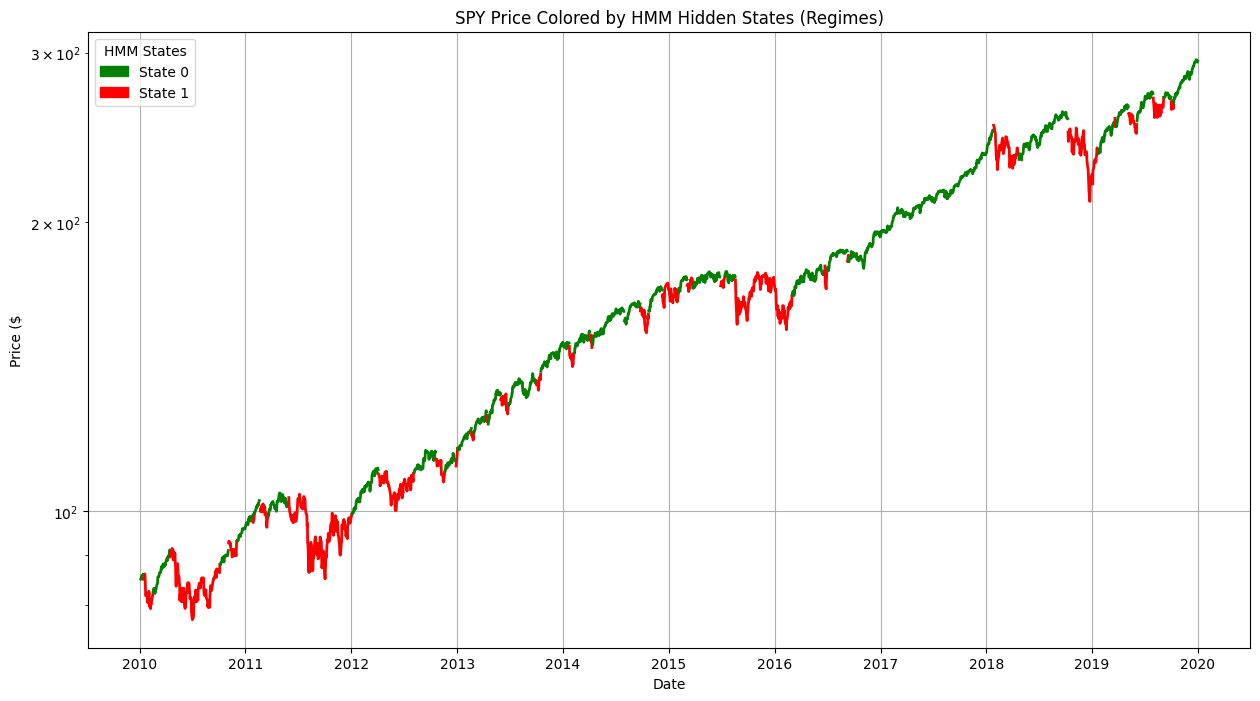

In [7]:
# SPY Price Feature Only Visualization
# ==========================================

plt.figure(figsize=(15, 8))

# Dynamically generate colors or provide enough for N_COMPONENTS
colors = ['green', 'red', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extended colors list
colors_map = {i: colors[i] for i in range(N_COMPONENTS)}

# Identify segments where the state is constant
# This creates a series that increments each time the state changes
state_segments = data['Regime'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in data.groupby(state_segments):
    state = segment_df['Regime'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['SPY'], color=color, linewidth=2) # Plot the segment as a line

plt.title(f"{TICKERS[0]} Price Colored by HMM Hidden States (Regimes)")
plt.xlabel("Date")
plt.ylabel("Price ($")

# Create a custom legend as plotting in a loop creates multiple labels
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log') # Useful for viewing multi-year index growth
plt.show()

### Out-of-Sample Performance Analysis (SPY-Only Model)

To evaluate how well the SPY-only HMM generalizes to new data, we will perform an out-of-sample analysis. This involves:

1.  **Redefining the training period:** We will retrain the SPY-only HMM on data up to a specific historical date (e.g., end of 2023).
2.  **Downloading 'live' data:** We will then download new data from that historical end date up to the present.
3.  **Predicting regimes on live data:** The historically trained HMM will be used to predict regimes on this unseen 'live' data.
4.  **Visualizing performance:** The SPY price in the 'live' period will be plotted, colored by the predicted HMM regimes, to visually inspect the model's performance.

In [8]:
import datetime

# Define the historical end date for SPY-only model training
SPY_ONLY_HIST_TRAIN_END_DATE = END_DATE

# Define the live analysis period
LIVE_START_DATE = (pd.to_datetime(SPY_ONLY_HIST_TRAIN_END_DATE) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
LIVE_END_DATE = datetime.date.today().strftime('%Y-%m-%d')

print(f"Original SPY-Only Model Training Start Date: {START_DATE}")
print(f"New SPY-Only Model Training End Date: {SPY_ONLY_HIST_TRAIN_END_DATE}")
print(f"Live Analysis Period: {LIVE_START_DATE} to {LIVE_END_DATE}")

Original SPY-Only Model Training Start Date: 2010-01-01
New SPY-Only Model Training End Date: 2020-01-01
Live Analysis Period: 2020-01-02 to 2026-06-12


First, we will re-download the SPY data for the historical training period and retrain the SPY-only HMM. We'll use the same `N_COMPONENTS=2` and manual initialization strategy as before to ensure consistency with the prior SPY-only analysis.

In [9]:
# 1. Re-download data for training the SPY-only model up to a historical date
temp_download_df = yf.download(TICKERS[0], start=START_DATE, end=SPY_ONLY_HIST_TRAIN_END_DATE)
train_data_spy = pd.DataFrame(temp_download_df['Close'])
train_data_spy.columns = ['SPY']
train_data_spy['SPY_Returns'] = train_data_spy['SPY'].pct_change() * 100
train_data_spy.dropna(inplace=True)

# 2. Re-scale and Re-train the SPY-only HMM
X_train_spy = train_data_spy[['SPY_Returns']].values
spy_only_scaler = StandardScaler()
X_train_scaled_spy = spy_only_scaler.fit_transform(X_train_spy)

# Re-initialize and Re-train the HMM for SPY-only (N_COMPONENTS=2)
spy_only_model = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=200,
    init_params="" # Disable random initialization
)

# Manual Initialization of means and covars (for N_COMPONENTS=2)
spy_only_model.means_ = np.array([
    [ 1.0],  # Regime 0 (Bull): High positive mean on scaled data
    [-1.0]   # Regime 1 (Bear): Low negative mean on scaled data
])
spy_only_model.covars_ = np.array([
    [0.2],  # Regime 0 (LOW Volatility)
    [3.0]   # Regime 1 (HIGH Volatility)
])
spy_only_model.transmat_ = np.full((2, 2), 1.0 / 2)
spy_only_model.startprob_ = np.full(2, 1.0 / 2)

spy_only_model.fit(X_train_scaled_spy)
print("SPY-only HMM re-trained for historical data.")

/tmp/ipykernel_20913/2907747309.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp_download_df = yf.download(TICKERS[0], start=START_DATE, end=SPY_ONLY_HIST_TRAIN_END_DATE)
[*********************100%***********************]  1 of 1 completed


SPY-only HMM re-trained for historical data.


Now, we will download data for the defined 'live' analysis period. We will then use the `spy_only_scaler` (fitted on the historical training data) to transform this new data, and the `spy_only_model` to predict the regimes. This provides an out-of-sample view of the model's regime detection.

/tmp/ipykernel_20913/117735553.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp_download_df_live = yf.download(TICKERS[0], start=LIVE_START_DATE, end=LIVE_END_DATE)
[*********************100%***********************]  1 of 1 completed


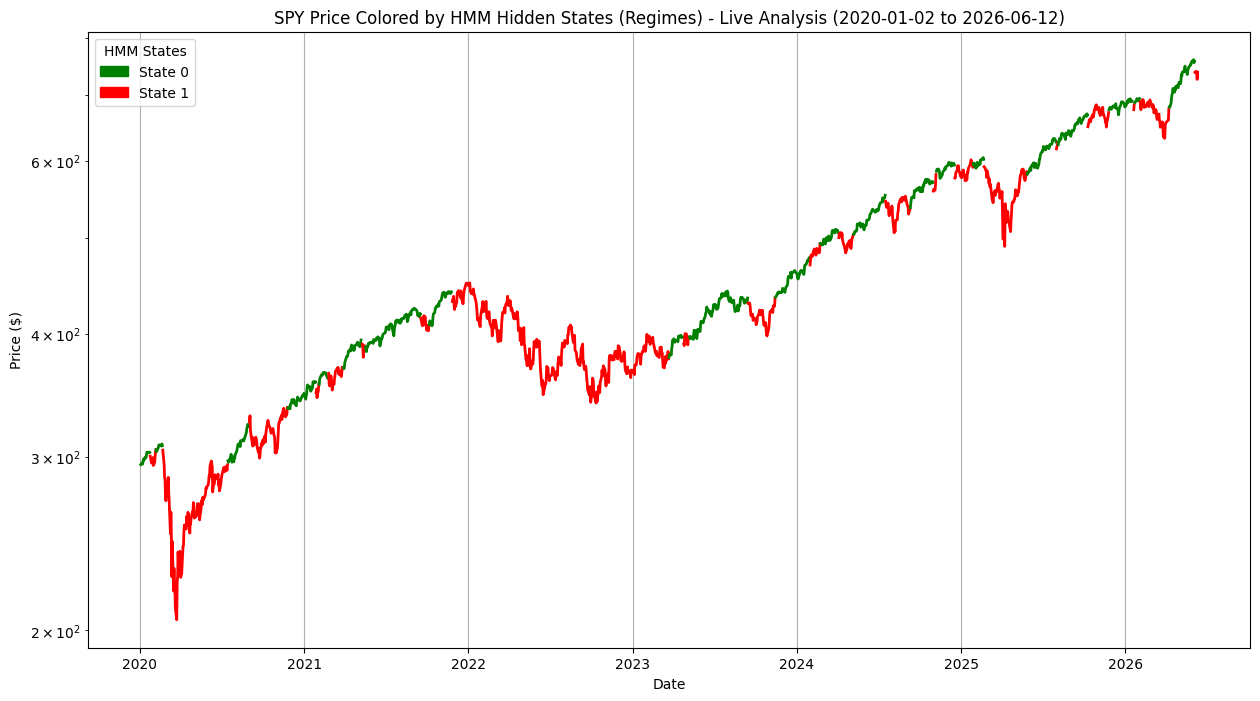

In [10]:
# 3. Download data for the live analysis period
temp_download_df_live = yf.download(TICKERS[0], start=LIVE_START_DATE, end=LIVE_END_DATE)
live_data_spy = pd.DataFrame(temp_download_df_live['Close'])
live_data_spy.columns = ['SPY']
live_data_spy['SPY_Returns'] = live_data_spy['SPY'].pct_change() * 100
live_data_spy.dropna(inplace=True)

if not live_data_spy.empty:
    # 4. Scale live data using the *trained* scaler and predict regimes
    X_live_spy = live_data_spy[['SPY_Returns']].values
    # IMPORTANT: Use .transform, not .fit_transform, as the scaler was already fitted on historical data
    X_live_scaled_spy = spy_only_scaler.transform(X_live_spy)
    live_data_spy['Regime'] = spy_only_model.predict(X_live_scaled_spy)

    # 5. Visualize the live data with predicted regimes
    plt.figure(figsize=(15, 8))
    colors = ['green', 'red'] # For N_COMPONENTS=2
    colors_map = {i: colors[i] for i in range(2)}

    state_segments_live = live_data_spy['Regime'].diff().ne(0).cumsum()

    for segment_id, segment_df in live_data_spy.groupby(state_segments_live):
        state = segment_df['Regime'].iloc[0]
        color = colors_map[state]
        plt.plot(segment_df.index, segment_df['SPY'], color=color, linewidth=2)

    plt.title(f"{TICKERS[0]} Price Colored by HMM Hidden States (Regimes) - Live Analysis ({LIVE_START_DATE} to {LIVE_END_DATE})")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")

    legend_handles_live = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
    plt.legend(handles=legend_handles_live, title="HMM States")

    plt.grid(True)
    plt.yscale('log')
    plt.show()
else:
    print(f"No live data available for the period {LIVE_START_DATE} to {LIVE_END_DATE}.")

This cell configures the stock tickers (SPY and VIX), date range, and HMM parameters. It then downloads the 'Close' prices for both and calculates their daily returns and changes as features for the HMM.

## SPY and VIX Features


In [11]:
# Configure HMM, download SPY/VIX data, calculate features
# --- Configuration ---
# Tickers
TICKERS = ['SPY', '^VIX']

# 1. Download Data
data = yf.download(TICKERS, start=START_DATE, end=END_DATE)['Close']
data.columns = ['SPY', 'VIX']

# 2. Feature Engineering
# SPY returns are key for direction/magnitude of movement
data['SPY_Returns'] = data['SPY'].pct_change() * 100

# VIX change is a good measure of increasing/decreasing fear/volatility
data['VIX_Change'] = data['VIX'].pct_change() * 100

# Drop the first row which contains NaN from the pct_change calculation
data.dropna(inplace=True)

# 3. Prepare Observation Data (X)
# We combine the two features: SPY Returns and VIX Change
# The HMM input (X) must be a 2D numpy array
X = data[['SPY_Returns', 'VIX_Change']].values

print(f"Data shape (Samples, Features): {X.shape}")

/tmp/ipykernel_20913/1381779515.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKERS, start=START_DATE, end=END_DATE)['Close']
[*********************100%***********************]  2 of 2 completed

Data shape (Samples, Features): (2515, 2)


This cell prepares the observation data by selecting 'SPY_Returns' and 'VIX_Change' and then applies standard scaling to these features for optimal HMM training.

### Feature Scaling

In [12]:
# Scale SPY and VIX features for HMM training
# 3. Prepare Observation Data (X) - BEFORE SCALING
X = data[['SPY_Returns', 'VIX_Change']].values

# --- NEW STEP: Apply Scaling ---
scaler = StandardScaler()
# Fit the scaler to the data and transform it
X_scaled = scaler.fit_transform(X)
# The HMM will now be trained on X_scaled

This cell initializes and trains a Gaussian Hidden Markov Model (HMM) using the scaled SPY and VIX data. It then predicts the hidden states (regimes) and adds them to the original DataFrame.

In [13]:
# Train HMM on scaled SPY/VIX data, predict regimes
# ... (Previous code for downloading data and creating 'data' DataFrame) ...

# 3. Prepare Observation Data (X) - BEFORE SCALING
X = data[['SPY_Returns', 'VIX_Change']].values

# --- NEW STEP: Apply Scaling ---
scaler = StandardScaler()
# Fit the scaler to the data and transform it
X_scaled = scaler.fit_transform(X)
# The HMM will now be trained on X_scaled

# 4. Initialize and Train the HMM using the SCALED data
model = hmm.GaussianHMM(
    n_components=N_COMPONENTS,
    covariance_type="full",
    n_iter=100,
    # Add n_init for better results (see section 2)
    #n_init=10
)

# Fit the model to the SCALED observation data
print("\nTraining HMM on scaled data...")
model.fit(X_scaled)
print("Training complete.")

# 5. Predict the Hidden States
hidden_states = model.predict(X_scaled) # Predict using the scaled data
data['Regime'] = hidden_states # Add states to the original data frame

# Now run your analysis again (Regime Analysis, Daily Comparison)
# The output should show multiple regimes.


Training HMM on scaled data...
Training complete.


This cell defines a function `train_best_hmm` that trains the HMM multiple times and returns the model with the highest log-likelihood score to improve robustness. It then applies this function to train the HMM and predict states.

In [14]:
# Train HMM with best log-likelihood, predict states
def train_best_hmm(X_scaled, n_components, n_attempts=10, n_iter=100):
    """
    Trains the GaussianHMM multiple times and returns the model
    with the highest log-likelihood score.
    """
    import numpy as np
    from hmmlearn import hmm

    best_score = -np.inf
    best_model = None

    print(f"Attempting HMM fit {n_attempts} times...")
    for i in range(n_attempts):
        # Initialize a new model for each attempt
        current_model = hmm.GaussianHMM(
            n_components=n_components,
            covariance_type="full",
            n_iter=n_iter
        )

        try:
            # Fit the model to the scaled data
            current_model.fit(X_scaled)
            current_score = current_model.score(X_scaled)

            if current_score > best_score:
                best_score = current_score
                best_model = current_model
                # print(f"  Attempt {i+1}: New Best Score = {best_score:.2f}")

        except Exception as e:
            # Handle potential training failures (e.g., singular matrix)
            # print(f"  Attempt {i+1}: Failed with error: {e}")
            continue

    if best_model is None:
        raise RuntimeError("HMM training failed for all attempts. Check data for issues.")

    print(f"Training complete. Best score: {best_score:.2f}")
    return best_model

# --- REPLACE YOUR ORIGINAL TRAINING BLOCK WITH THIS ---
# X_scaled must be available from your previous scaling step
model = train_best_hmm(X_scaled, n_components=N_COMPONENTS, n_attempts=20, n_iter=200)

# 5. Predict the Hidden States using the best model
hidden_states = model.predict(X_scaled)
data['Regime'] = hidden_states
# Now run your regime analysis and daily comparison


Attempting HMM fit 20 times...
Training complete. Best score: -5151.66


This cell conducts a detailed analysis of the regimes, calculating means and standard deviations for SPY Returns and VIX Change. It also identifies bullish/bearish regimes and predicts the most likely regime for the next day based on transition probabilities.

In [15]:
# Analyze regimes, predict next day's regime
# 6. Analyze the Regimes
print("\n--- Regime Analysis (Mean of Features) ---")
regime_analysis = data.groupby('Regime')[['SPY_Returns', 'VIX_Change']].mean()
print(regime_analysis)

# 7. Directional Prediction Insight
# Identify the most "Bullish" and "Bearish" regimes
# Sort by SPY_Returns to find the order
sorted_regimes = regime_analysis.sort_values(by='SPY_Returns', ascending=False)

print("\n### 📊 Comprehensive Regime Analysis (Count, Mean, and Volatility) ###")

# 1. Group the data by the 'Regime' column
regime_groups = data.groupby('Regime')

# 2. Calculate Count, Mean, and Standard Deviation for SPY_Returns and VIX_Change
regime_stats = regime_groups[['SPY_Returns', 'VIX_Change']].agg(
    # Count of samples (days) in the regime
    Count=('SPY_Returns', 'size'),
    # Mean of SPY Returns for directional insight
    SPY_Returns_Mean=('SPY_Returns', 'mean'),
    # Standard Deviation of SPY Returns for volatility insight
    SPY_Returns_Std_Dev=('SPY_Returns', 'std'),
    # Mean of VIX Change (for confirming volatility behavior)
    VIX_Change_Mean=('VIX_Change', 'mean')
)

# 3. Print the resulting statistics
print(regime_stats.round(4))

print("\n--- Directional Insight ---")
print(f"The most **Bullish Regime** (highest positive SPY Return) is Regime **{sorted_regimes.index[0]}**")
print(f"The most **Bearish Regime** (highest negative SPY Return) is Regime **{sorted_regimes.index[-1]}**")

# 8. Making a Forward Prediction (The core step)
# To predict the next day's regime, you use the HMM's transition matrix and the current state.
# Let's get the state of the *last* day in the dataset
current_regime = data['Regime'].iloc[-1]
transition_matrix = model.transmat_

# Get the transition probabilities from the current regime to all others
next_state_probs = transition_matrix[current_regime]

print("\n--- Next Day Regime Probability ---")
print(f"Current Regime (Today's Close): **Regime {current_regime}**")
print("Probability of transitioning to each regime tomorrow:")
for i in range(N_COMPONENTS):
    # Lookup the mean SPY return for this predicted state
    mean_return = regime_analysis.loc[i, 'SPY_Returns']
    print(f"  - Regime {i}: {next_state_probs[i]:.2f} (Avg SPY Return: {mean_return:.2f}%)")

# The regime with the highest probability is your prediction
predicted_next_regime = np.argmax(next_state_probs)
predicted_return = regime_analysis.loc[predicted_next_regime, 'SPY_Returns']

print(f"\n**Prediction:** The most likely regime for tomorrow is **Regime {predicted_next_regime}** with an expected average SPY return of **{predicted_return:.2f}%**.")


--- Regime Analysis (Mean of Features) ---
        SPY_Returns  VIX_Change
Regime                         
0          0.119937   -0.424990
1         -0.232685    3.406913

### 📊 Comprehensive Regime Analysis (Count, Mean, and Volatility) ###
        Count  SPY_Returns_Mean  SPY_Returns_Std_Dev  VIX_Change_Mean
Regime                                                               
0        2043            0.1199               0.5806          -0.4250
1         472           -0.2327               1.7348           3.4069

--- Directional Insight ---
The most **Bullish Regime** (highest positive SPY Return) is Regime **0**
The most **Bearish Regime** (highest negative SPY Return) is Regime **1**

--- Next Day Regime Probability ---
Current Regime (Today's Close): **Regime 0**
Probability of transitioning to each regime tomorrow:
  - Regime 0: 0.93 (Avg SPY Return: 0.12%)
  - Regime 1: 0.07 (Avg SPY Return: -0.23%)

**Prediction:** The most likely regime for tomorrow is **Regime 0** with an 

This cell defines a function `train_hmm_with_initial_volatility` to initialize the HMM with distinct volatility parameters, forcing a separation between stable and crisis regimes. It then applies this function to train the HMM and predict states.

---
## Initialize the Variance Manually
---


In [16]:
# Train HMM with initialized volatility parameters
def train_hmm_with_initial_volatility(X_scaled, n_components, stable_volatility=0.2, crash_volatility=2.0):
    """Initializes HMM with distinct volatility parameters to force separation."""
    from hmmlearn import hmm
    import numpy as np

    # Initialize the model, but tell it NOT to randomize parameters (init_params="")
    model = hmm.GaussianHMM(
        n_components=n_components,
        covariance_type="full",
        n_iter=200,
        init_params="" # Important: Prevents default random initialization
    )

    # 1. Initialize Covariance Matrix (Variance)
    # This matrix is [n_components, n_features, n_features]
    # We assume Regime 0 (Bull) is low vol, Regime 2 (Bear) is high vol.
    covars_init = np.zeros((n_components, X_scaled.shape[1], X_scaled.shape[1]))

    # Set initial low variance for the 'stable' regimes (e.g., Regime 0 and 1)
    # We use stable_volatility for the diagonal of the covariance matrix
    # (since the data is scaled, 0.2 and 2.0 are relative values)
    stable_cov_val = stable_volatility ** 2
    for i in range(n_components - 1): # Apply to regimes 0 and 1
        np.fill_diagonal(covars_init[i], stable_cov_val)

    # Set initial high variance for the 'crisis' regime (e.g., Regime 2)
    crash_cov_val = crash_volatility ** 2
    np.fill_diagonal(covars_init[n_components - 1], crash_cov_val)

    model.covars_ = covars_init

    # 2. Initialize Transition and Start Probabilities (optional, but good practice)
    # You can leave these random, but explicitly setting them is safer.
    model.transmat_ = np.full((n_components, n_components), 1.0 / n_components)
    model.startprob_ = np.full(n_components, 1.0 / n_components)

    # 3. Fit the model
    # Note: Mean (means_) is still randomly initialized and learned in the fit process
    model.fit(X_scaled)

    return model

# --- RERUN YOUR TRAINING WITH THE NEW FUNCTION ---
# You can try a new set of volatile starting values if the default 0.2/2.0 fails
model = train_hmm_with_initial_volatility(
    X_scaled,
    n_components=N_COMPONENTS,
    stable_volatility=0.2,
    crash_volatility=2.0
)

# Predict and check results...
hidden_states = model.predict(X_scaled)
data['Regime'] = hidden_states

This cell displays the SPY returns, VIX changes, and the predicted regime for the last 30 days after training the HMM with manually initialized volatility parameters.

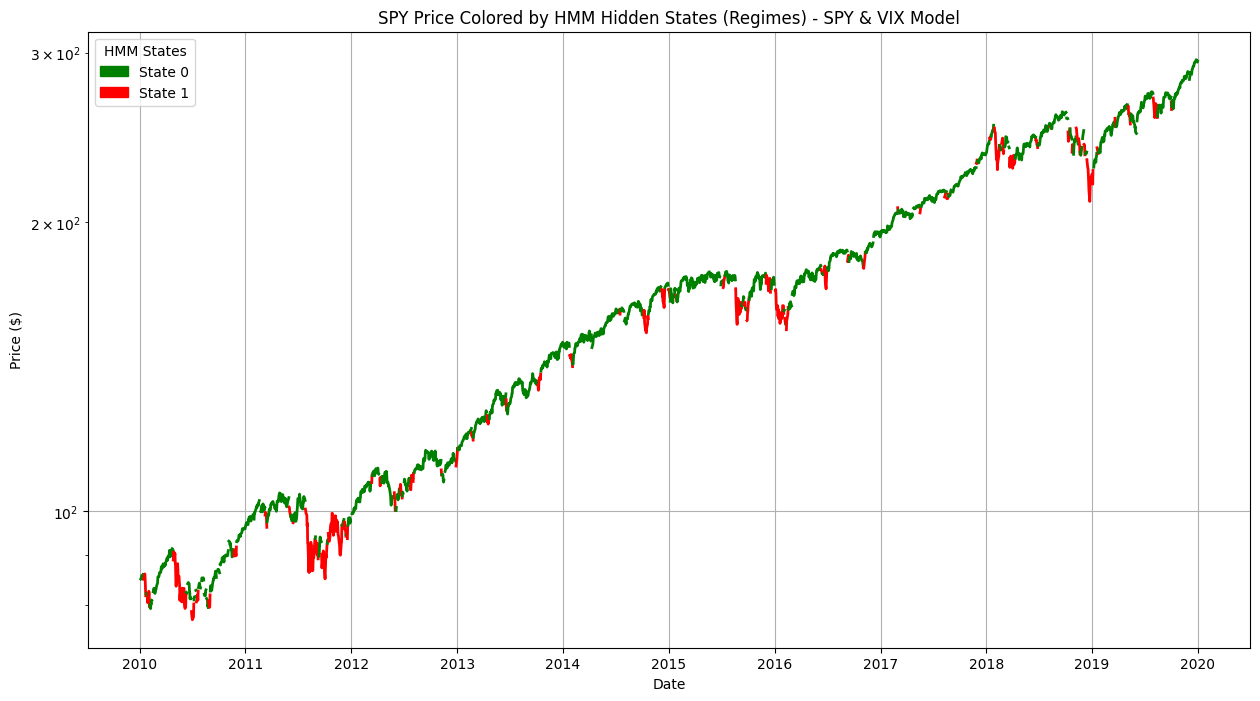

In [17]:
# SPY and VIX Feature Visualization
# ==========================================

plt.figure(figsize=(15, 8))

# Dynamically generate colors or provide enough for N_COMPONENTS
colors = ['green', 'red', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extended colors list
colors_map = {i: colors[i] for i in range(N_COMPONENTS)}

# Identify segments where the state is constant
# This creates a series that increments each time the state changes
state_segments = data['Regime'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in data.groupby(state_segments):
    state = segment_df['Regime'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['SPY'], color=color, linewidth=2) # Plot the segment as a line

plt.title(f"{TICKERS[0]} Price Colored by HMM Hidden States (Regimes) - SPY & VIX Model")
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend as plotting in a loop creates multiple labels
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log') # Useful for viewing multi-year index growth
plt.show()

### Out-of-Sample Performance Analysis (SPY & VIX Model)

Similar to the SPY-only model, we will perform an out-of-sample analysis for the HMM trained on both SPY returns and VIX changes. This helps evaluate the model's generalization capability on unseen data.

In [18]:
# Define the historical end date for SPY & VIX model training
# We'll use the same END_DATE as the in-sample analysis for this test.
SPY_VIX_HIST_TRAIN_END_DATE = END_DATE

# The LIVE_START_DATE and LIVE_END_DATE are already defined based on END_DATE

print(f"SPY & VIX Model Training Start Date: {START_DATE}")
print(f"SPY & VIX Model Training End Date: {SPY_VIX_HIST_TRAIN_END_DATE}")
print(f"Live Analysis Period: {LIVE_START_DATE} to {LIVE_END_DATE}")

SPY & VIX Model Training Start Date: 2010-01-01
SPY & VIX Model Training End Date: 2020-01-01
Live Analysis Period: 2020-01-02 to 2026-06-12


First, we re-download the SPY and VIX data for the historical training period and retrain the HMM. We'll use the `train_hmm_with_initial_volatility` function to maintain the distinct volatility initialization strategy.

In [19]:
# 1. Re-download data for training the SPY & VIX model up to a historical date
temp_download_df_vix = yf.download(TICKERS, start=START_DATE, end=SPY_VIX_HIST_TRAIN_END_DATE)['Close']
train_data_spy_vix = pd.DataFrame(temp_download_df_vix)
train_data_spy_vix.columns = ['SPY', 'VIX']

# Feature Engineering for historical training data
train_data_spy_vix['SPY_Returns'] = train_data_spy_vix['SPY'].pct_change() * 100
train_data_spy_vix['VIX_Change'] = train_data_spy_vix['VIX'].pct_change() * 100
train_data_spy_vix.dropna(inplace=True)

# 2. Re-scale and Re-train the SPY & VIX HMM
X_train_spy_vix = train_data_spy_vix[['SPY_Returns', 'VIX_Change']].values
spy_vix_scaler = StandardScaler()
X_train_scaled_spy_vix = spy_vix_scaler.fit_transform(X_train_spy_vix)

# Re-initialize and Re-train the HMM for SPY & VIX using initial volatility
spy_vix_model = train_hmm_with_initial_volatility(
    X_train_scaled_spy_vix,
    n_components=N_COMPONENTS,
    stable_volatility=0.2,
    crash_volatility=2.0
)

print("SPY & VIX HMM re-trained for historical data.")

/tmp/ipykernel_20913/1303475023.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp_download_df_vix = yf.download(TICKERS, start=START_DATE, end=SPY_VIX_HIST_TRAIN_END_DATE)['Close']
[*********************100%***********************]  2 of 2 completed


SPY & VIX HMM re-trained for historical data.


Now, we download data for the defined 'live' analysis period. We use the `spy_vix_scaler` (fitted on the historical training data) to transform this new data, and the `spy_vix_model` to predict the regimes. This provides an out-of-sample view of the model's regime detection for the combined features.

In [20]:
# 3. Download data for the live analysis period
temp_download_df_live_vix = yf.download(TICKERS, start=LIVE_START_DATE, end=LIVE_END_DATE)['Close']
live_data_spy_vix = pd.DataFrame(temp_download_df_live_vix)
live_data_spy_vix.columns = ['SPY', 'VIX']

# Feature Engineering for live data
live_data_spy_vix['SPY_Returns'] = live_data_spy_vix['SPY'].pct_change() * 100
live_data_spy_vix['VIX_Change'] = live_data_spy_vix['VIX'].pct_change() * 100
live_data_spy_vix.dropna(inplace=True)

if not live_data_spy_vix.empty:
    # 4. Scale live data using the *trained* scaler and predict regimes
    X_live_spy_vix = live_data_spy_vix[['SPY_Returns', 'VIX_Change']].values
    # IMPORTANT: Use .transform, not .fit_transform
    X_live_scaled_spy_vix = spy_vix_scaler.transform(X_live_spy_vix)
    live_data_spy_vix['Regime'] = spy_vix_model.predict(X_live_scaled_spy_vix)

    print("Regimes predicted for live SPY & VIX data.")
else:
    print(f"No live data available for the period {LIVE_START_DATE} to {LIVE_END_DATE} for SPY and VIX.")

/tmp/ipykernel_20913/2537859570.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp_download_df_live_vix = yf.download(TICKERS, start=LIVE_START_DATE, end=LIVE_END_DATE)['Close']
[*********************100%***********************]  2 of 2 completed


Regimes predicted for live SPY & VIX data.


/tmp/ipykernel_20913/2537859570.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  live_data_spy_vix['SPY_Returns'] = live_data_spy_vix['SPY'].pct_change() * 100


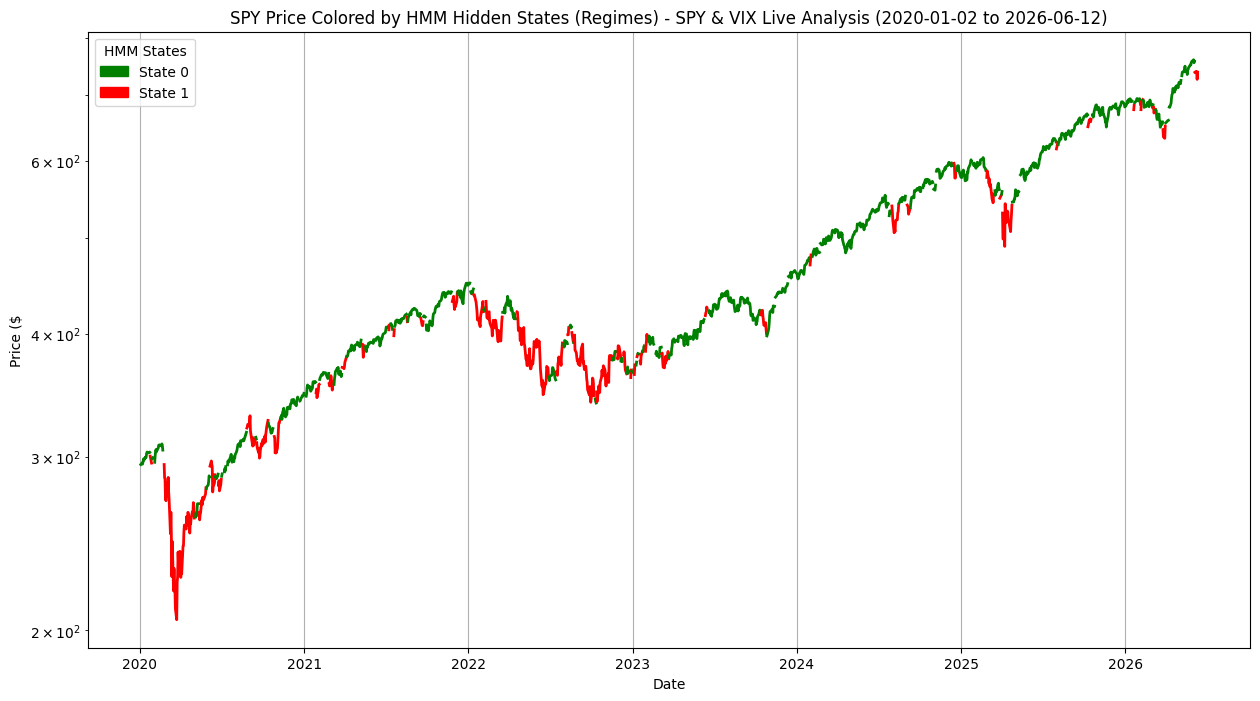

In [21]:
# 5. Visualize the live SPY price with predicted regimes (SPY & VIX Model)

if not live_data_spy_vix.empty:
    plt.figure(figsize=(15, 8))

    # Dynamically generate colors or provide enough for N_COMPONENTS
    colors = ['green', 'red', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extended colors list
    colors_map = {i: colors[i] for i in range(N_COMPONENTS)}

    # Identify segments where the state is constant
    state_segments_live_vix = live_data_spy_vix['Regime'].diff().ne(0).cumsum()

    # Plot each segment with its corresponding state color
    for segment_id, segment_df in live_data_spy_vix.groupby(state_segments_live_vix):
        state = segment_df['Regime'].iloc[0]
        color = colors_map[state]
        plt.plot(segment_df.index, segment_df['SPY'], color=color, linewidth=2)

    plt.title(f"{TICKERS[0]} Price Colored by HMM Hidden States (Regimes) - SPY & VIX Live Analysis ({LIVE_START_DATE} to {LIVE_END_DATE})")
    plt.xlabel("Date")
    plt.ylabel("Price ($")

    legend_handles_live_vix = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
    plt.legend(handles=legend_handles_live_vix, title="HMM States")

    plt.grid(True)
    plt.yscale('log')
    plt.show()
else:
    print("Cannot visualize: No live data available for SPY and VIX.")